# Introduction to Neural Networks

In this activity, you will implement a simple feedforward neural network from scratch using Python. We will use the popular MNIST dataset, which consists of handwritten digits, to train our neural network.

In [28]:
import numpy as np
import gzip
from pathlib import Path
import matplotlib.pyplot as plt
from networkx.algorithms.tree import minimum_spanning_tree
from tqdm import tqdm
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn

import seaborn as sns


## MNIST dataset

This is a classic dataset in machine learning, consisting of 60,000 training images and 10,000 test images of handwritten digits (0-9). Each image is a 28x28 pixel grayscale image, which can be flattened into a 784-dimensional vector for input into our neural network. The goal is to classify each image into one of the 10 digit classes. The following code will load them into memory.

In [31]:
transform = transforms.ToTensor()

# MNIST dataset
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Test set
test_dataset = datasets.MNIST(
    root='./data',
    train=False,          # Load test set
    download=True,
    transform=transform
)

train_size = 50000
val_size = 10000
# Split the training dataset into train and validation sets.
train_set, val_set = random_split(train_dataset, [train_size, val_size])

print("train:", len(train_set), "val:", len(val_set), "test:", len(test_dataset))


train: 50000 val: 10000 test: 10000


In [34]:
batch_size = 256

train_loader = DataLoader(train_set, batch_size = batch_size, shuffle = True)
val_loader = DataLoader(val_set, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)

Training batches: 196
Validation batches: 40
Test batches: 40
Batch shape: torch.Size([256, 1, 28, 28]), Labels shape: torch.Size([256])


We can also use matplotlib to visualize the images in the dataset. Each image is a 28x28 pixel grayscale image, which can be displayed using the `imshow` function from matplotlib.

In [24]:
def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.reshape((28,28)), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

Every time you run this cell, a random number from the training set will be displayed. You can run it multiple times to see different images from the dataset.

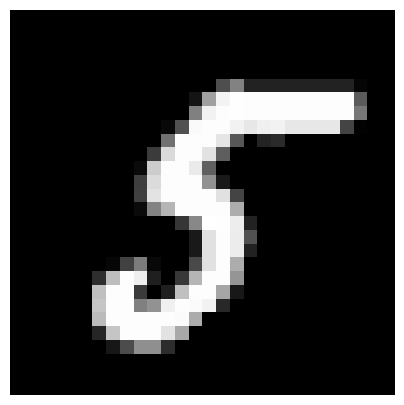

'Label: 5'

In [32]:
random_idx = np.random.randint(0, x_train.shape[0])
plot_number(x_train[random_idx])
display(f"Label: {y_train[random_idx].squeeze()}")

## Defining the Neural Network

In [ ]:
class FeedForwardNN(nn.Module):
    def __init__(self, input_size=784, hidden_size=200, output_size=10):
        super(FeedForwardNN, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

## Training the Neural Network

Let's apply standard scaling to the input data. Since we are not using sklearn, we will implement it ourselves. We will calculate the mean and standard deviation of the training data, and then use those values to scale the training, validation, and test sets.

When training a neural network, it is common to use mini-batch gradient descent. This means that instead of updating the weights after every single training example, we will update them after a small batch of examples. This can help to stabilize the training process and can also speed up convergence. The following function will create mini-batches from the training data.

We also need to define our loss function. For multi-class classification, a common choice is the softmax cross-entropy loss. This loss function combines the softmax activation function with the cross-entropy loss, which measures the difference between the predicted probabilities and the true labels. The following function will compute the softmax cross-entropy loss and also calculate the gradients needed for backpropagation.

Let's also create the accuracy function to measure the performance of our model on the validation set during training.

Let's now define the training loop for our neural network. In each epoch, we will iterate over the mini-batches of the training data, perform a forward pass to compute the predictions, calculate the loss and gradients using the softmax cross-entropy function, perform a backward pass to compute the gradients for each layer, and then update the weights using gradient descent. After each epoch, we will also evaluate the accuracy on the validation set.

Let's now define our neural network architecture. It has three layers:
- Input layer with 784 neurons (one for each pixel in the input image)
- Hidden layer with 200 neurons and ReLU activation
- Output layer with 10 neurons (one for each class) and no activation function (since we will apply the softmax function in the loss function)

Set up our training parameters and start training the model.

## Testing the model

With the model trained, we can now evaluate its performance on the test set. We will use the same accuracy function that we defined earlier to measure the accuracy of the model on the test set.

We can also visualize the confusion matrix.